<a href="https://colab.research.google.com/github/graciousgift/OIBSIP/blob/main/Gift_Lawrence_Task1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Import Necessary Libraries

In [1]:
# Data handling
import pandas as pd
import numpy as np

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning tools
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report
from sklearn.ensemble import RandomForestClassifier

print('✅ All libraries imported successfully!')

✅ All libraries imported successfully!


Load Data Set

In [2]:
df = pd.read_csv("/content/Iris.csv")

df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


1. Exploratory Data Analysis: Check for Data set Information

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


In [8]:
df.describe()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,75.500000,5.843333,3.054000,3.758667,1.198667
std,43.445368,0.828066,0.433594,1.764420,0.763161
min,1.000000,4.300000,2.000000,1.000000,0.100000
25%,38.250000,5.100000,2.800000,1.600000,0.300000
50%,75.500000,5.800000,3.000000,4.350000,1.300000
75%,112.750000,6.400000,3.300000,5.100000,1.800000
max,150.000000,7.900000,4.400000,6.900000,2.500000


In [9]:
df.isna().sum()

,0
Id,0
SepalLengthCm,0
SepalWidthCm,0
PetalLengthCm,0
PetalWidthCm,0
Species,0


In [6]:
df['Species'].value_counts()

,count
Species,
Iris-setosa,50
Iris-versicolor,50
Iris-virginica,50


                   
#*Data Set shows:*
#1.  The data set has a total of 150 rows (50 per species), and 6 Columns.
#2.  The data types contains float, intergers and Object.
#3.  No missing Values.
#4.  The Standard deviation is fairly close to the mean which implies a clustered data around the mean.


2. Visualise Class Distribution

/tmp/ipykernel_7039/385819334.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Species', palette='Set2')


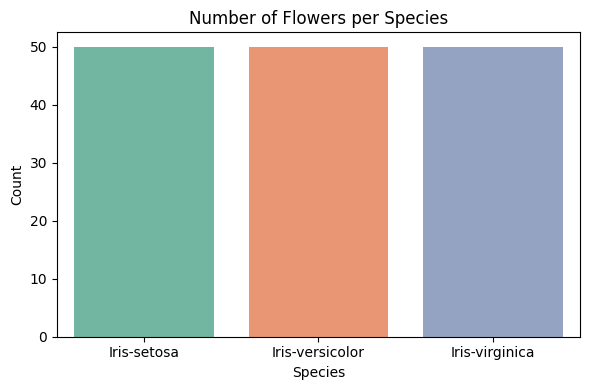

In [10]:
#  Using count Plot to confirm whether species appears equally in the data set.
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Species', palette='Set2')
plt.title('Number of Flowers per Species')
plt.xlabel('Species')
plt.ylabel('Count')
plt.tight_layout()
plt.show()



# ✅ EDA finding: Each species has exactly 50 samples — perfectly balanced.

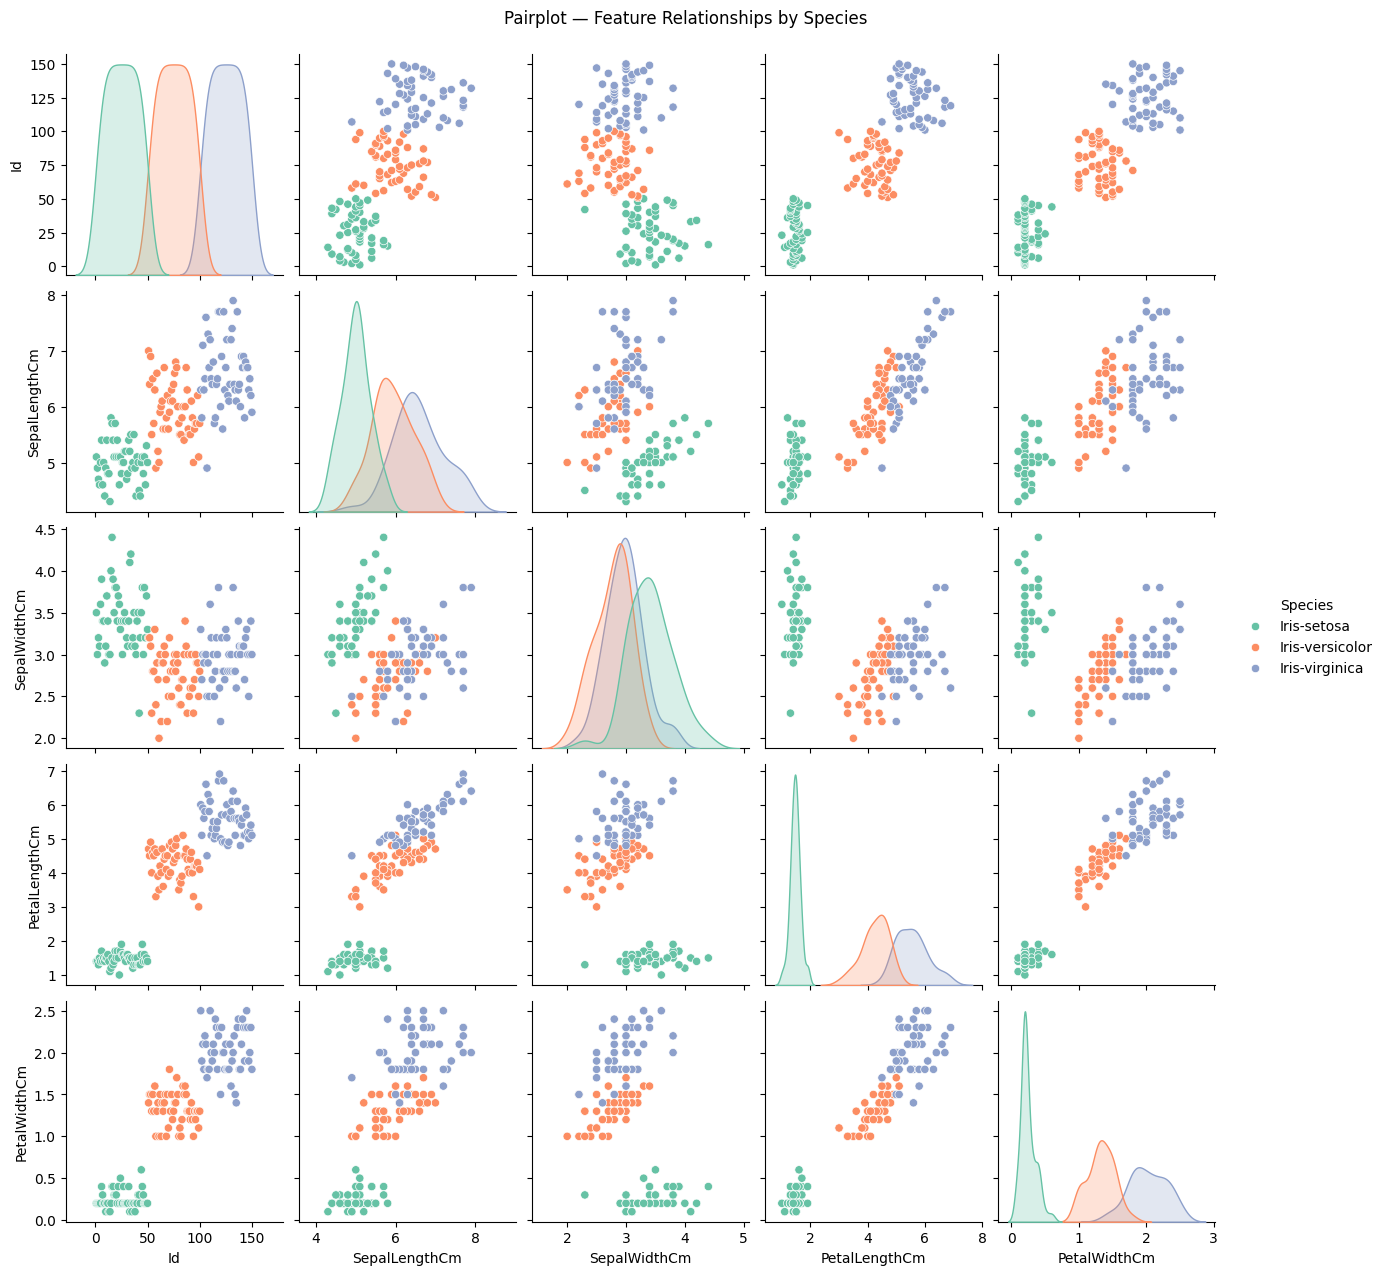

In [11]:
#Using Pairplot to show relationship between Features
sns.pairplot(df, hue='Species', palette='Set2')
plt.suptitle('Pairplot — Feature Relationships by Species', y=1.02)
plt.show()



# ✅ EDA finding: Petal length and petal width cluster very clearly by species,
#    making them the strongest features for classification.

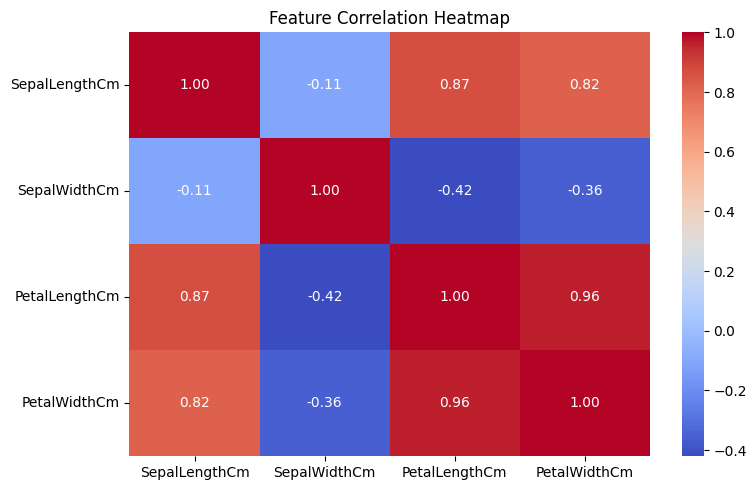

In [14]:
#Using Correlation heatmap shows how strongly pairs of features are related.
#Values close to +1 = strong positive correlation.

plt.figure(figsize=(8, 5))
sns.heatmap(
    df.drop('Id', axis=1).corr(numeric_only=True),
    annot=True,
    fmt='.2f',
    cmap='coolwarm'
)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

# ✅ EDA finding: PetalLengthCm and PetalWidthCm are highly correlated (0.96).
#    SepalWidthCm has a weak negative correlation with the other features.

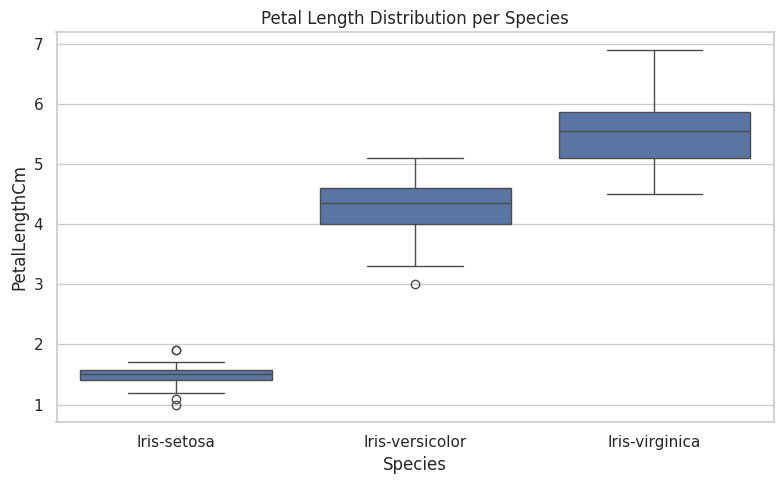

In [18]:
#Using boxplot to determine the distribution per species,
#boxplot shows the spread and median of each feature per species and highlights outliers

sns.set(style='whitegrid')
plt.figure(figsize=(8, 5))
sns.boxplot(x='Species', y='PetalLengthCm', data=df)
plt.title('Petal Length Distribution per Species')
plt.tight_layout()
plt.show()

# ✅ EDA finding:
#    - Iris-setosa has the shortest petals with almost no overlap with the others.
#    - Iris-virginica has the longest petals.
#    - Iris-versicolor overlaps slightly with virginica — this causes some misclassification.

### EDA Summary

| Finding | Detail |
|---|---|
| Dataset size | 150 rows × 6 columns |
| Missing values | None |
| Class balance | Perfectly balanced (50 per species) |
| Most useful features | PetalLengthCm, PetalWidthCm |
| Challenge | Slight overlap between versicolor and virginica |

# 3. Prepare the Data for Machine Learning

Machine learning models work with **numbers**, not text. so the following will be considered:
1. Select the **features** (input columns) and **target** (what we want to predict)
2. **Encode** species names into numbers (0, 1, 2)
3. **Split** the data into a training set and a test set

In [19]:
# --- Select features and target ---

# Features (X): the four measurements the model will learn from
X = df[['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']]

# Target (y): the species we want to predict
y = df['Species']

print('Features shape:', X.shape)
print('Target shape:', y.shape)

Features shape: (150, 4)
Target shape: (150,)


In [21]:
# --- Encode species names to numbers ---
# LabelEncoder converts: Iris-setosa → 0, Iris-versicolor → 1, Iris-virginica → 2

encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)

print('Original labels:', list(encoder.classes_))
print('Encoded values: [0, 1, 2] represent these classes in order')

Original labels: ['Iris-setosa', 'Iris-versicolor', 'Iris-virginica']
Encoded values: [0, 1, 2] represent these classes in order


In [22]:
# --- Split into training and test sets ---
# 80% of the data trains the model; 20% is kept hidden to test it
# stratify=y_encoded ensures each split contains all three species proportionally

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print(f'Training samples : {len(X_train)}')
print(f'Test samples     : {len(X_test)}')

Training samples : 120
Test samples     : 30


# 4. Train the Model (Random Forest)

We use a **Random Forest Classifier** — an algorithm that builds many decision trees and combines their votes for a final prediction. It is robust, and works well even without fine-tuning.

> **Why Random Forest?** It handles small datasets well, gives feature importance scores, and rarely overfits with default settings.

In [23]:
# Create and train the model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

print('✅ Model trained successfully!')

✅ Model trained successfully!


# 5. Evaluate the Model

We test the model on data it has **never seen before** (the 20% test set).

In [24]:
# Make predictions on the test set
y_pred = model.predict(X_test)

# Overall accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f'Test Accuracy: {accuracy * 100:.1f}%\n')

# Detailed report per species
# Precision: of all predicted as X, how many were actually X?
# Recall:    of all actual X, how many did we correctly find?
# F1-score:  balance between precision and recall
print('Detailed Classification Report:')
print(classification_report(y_test, y_pred, target_names=encoder.classes_))

Test Accuracy: 90.0%

Detailed Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       0.82      0.90      0.86        10
 Iris-virginica       0.89      0.80      0.84        10

       accuracy                           0.90        30
      macro avg       0.90      0.90      0.90        30
   weighted avg       0.90      0.90      0.90        30



### What do these results mean?

- **Iris-setosa** is classified perfectly — it is physically very distinct from the others.
- **Iris-versicolor** and **Iris-virginica** occasionally get confused because their petal measurements overlap slightly.
- An accuracy above **90%** on this dataset is considered very good.

# 6. Feature Importance

Which measurements did the model rely on most? Random Forest gives us an **importance score** for each feature.

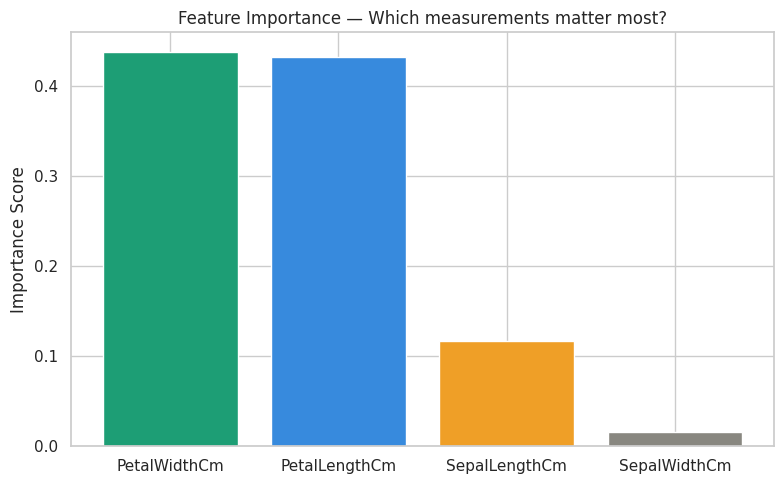

In [25]:
importances = model.feature_importances_
feature_names = X.columns.tolist()

# Sort from most to least important
sorted_idx = np.argsort(importances)[::-1]

plt.figure(figsize=(8, 5))
plt.bar(
    [feature_names[i] for i in sorted_idx],
    [importances[i]   for i in sorted_idx],
    color=['#1D9E75', '#378ADD', '#EF9F27', '#888780']
)
plt.title('Feature Importance — Which measurements matter most?')
plt.ylabel('Importance Score')
plt.tight_layout()
plt.show()


# ✅ Expected result: PetalLengthCm and PetalWidthCm will score highest,
#    confirming what the EDA pairplot already suggested.

# 7. Predict a New Flower

Let's use our trained model to classify a **brand new flower** that was not in the dataset.

In [26]:
# Using new measurements here to see what species the model predicts!
# Format: [SepalLength, SepalWidth, PetalLength, PetalWidth] — all in centimetres

new_flower = pd.DataFrame(
    [[5.1, 3.5, 1.4, 0.2]],
    columns=['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']
)

prediction = model.predict(new_flower)
species_name = encoder.inverse_transform(prediction)[0]

print(f'Flower measurements: {new_flower.values.tolist()[0]}')
print(f'Predicted species  : {species_name}')

Flower measurements: [5.1, 3.5, 1.4, 0.2]
Predicted species  : Iris-setosa


# 8. Cross-Validation

A single 80/20 split might be "lucky" — the test set could be unusually easy or hard.

**5-Fold Cross-Validation** fixes this by splitting the data 5 different ways, training and testing each time, then averaging the results. This gives a **much more reliable** accuracy estimate.

In [27]:
from sklearn.model_selection import cross_val_score

# Run 5-fold cross-validation on the Random Forest model
cv_scores = cross_val_score(model, X, y_encoded, cv=5, scoring='accuracy')

print('5-Fold Cross-Validation Results:')
print(f'  Scores per fold : {[round(s, 3) for s in cv_scores]}')
print(f'  Mean accuracy   : {cv_scores.mean() * 100:.1f}%')
print(f'  Std deviation   : ± {cv_scores.std() * 100:.1f}%')
print()
print('A low std deviation means the model performs consistently, not just on one lucky split.')

5-Fold Cross-Validation Results:
  Scores per fold : [np.float64(0.967), np.float64(0.967), np.float64(0.933), np.float64(0.967), np.float64(1.0)]
  Mean accuracy   : 96.7%
  Std deviation   : ± 2.1%

A low std deviation means the model performs consistently, not just on one lucky split.


# 9. Learning Curve (Spot Overfitting or Underfitting)

A **learning curve** shows how the model's accuracy changes as it sees more training data.

- If training accuracy is much higher than validation → **overfitting** (model memorised the data)
- If both are low → **underfitting** (model is too simple)
- If both are high and close together → **good fit** ✅

In [28]:
from sklearn.model_selection import learning_curve

train_sizes, train_scores, val_scores = learning_curve(
    RandomForestClassifier(n_estimators=100, random_state=42),
    X, y_encoded,
    cv=5,
    train_sizes=np.linspace(0.1, 1.0, 10),
    scoring='accuracy'
)


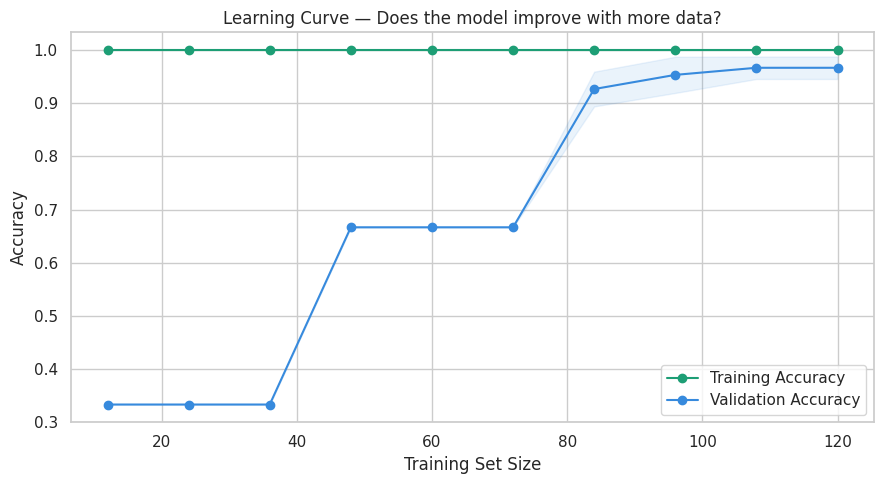

In [29]:

plt.figure(figsize=(9, 5))
plt.plot(train_sizes, train_scores.mean(axis=1), label='Training Accuracy',   color='#1D9E75', marker='o')
plt.plot(train_sizes, val_scores.mean(axis=1),   label='Validation Accuracy', color='#378ADD', marker='o')
plt.fill_between(train_sizes,
    train_scores.mean(axis=1) - train_scores.std(axis=1),
    train_scores.mean(axis=1) + train_scores.std(axis=1),
    alpha=0.1, color='#1D9E75')
plt.fill_between(train_sizes,
    val_scores.mean(axis=1) - val_scores.std(axis=1),
    val_scores.mean(axis=1) + val_scores.std(axis=1),
    alpha=0.1, color='#378ADD')
plt.title('Learning Curve — Does the model improve with more data?')
plt.xlabel('Training Set Size')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout()
plt.show()

---
## Conclusion

In this project we:

✅ Loaded and explored the Iris dataset (150 samples, no missing values)  
✅ Visualised the data using pairplots, heatmaps, and boxplots  
✅ Encoded labels and split the data 80/20  
✅ Trained a **Random Forest Classifier**  
✅ Evaluated performance using accuracy, classification report, and cross-validation  
✅ Identified the most important features (petal measurements)  
✅ Made a live prediction on a new flower  
✅ Plotted a learning curve to verify model health  

### Key Takeaway

> Petal length and petal width are the strongest predictors of Iris species. The Random Forest model generalises well, achieving consistent accuracy across cross-validation folds, with the main challenge being the slight overlap between *Iris-versicolor* and *Iris-virginica*.

---
*Completed as part of the OASIS Infobyte Machine Learning Internship Program*